In [63]:
# Q3: Feature Engineering and Regression Pipeline

# This notebook builds a reproducible machine learning pipeline to predict
# `items_sold` using retail transaction data.

In [64]:
# 1. Date Feature Engineering

# We extract useful temporal features from the transaction date.

In [65]:
import pandas as pd

# Load dataset
df = pd.read_csv('q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month-end flag
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Show sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [66]:
# The new features capture temporal patterns such as seasonality (month), weekly
# trends (day_of_week), and end-of-month effects (is_month_end)
# which can influence sales.

In [67]:
# 2. Temporal Train-Test Split

In [68]:
# Sort by date
df = df.sort_values('transaction_date')

# Split (80% train, 20% test)
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

In [69]:
# A random split is inappropriate for time-series data because it can lead to data leakage.

# Using future data to predict past outcomes results in unrealistic model performance.
# A temporal split ensures the model is evaluated on unseen future data, reflecting
# real-world conditions.

In [70]:
# 3. Preprocessing Pipeline

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical = ['promotion_type', 'location_type', 'store_size']
numerical = ['competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [72]:
# The pipeline ensures:
# - Categorical variables are properly encoded
# - Numerical features are scaled
# - Preprocessing is applied consistently to both training and test data

# Importantly, the pipeline is fit only on the training data to prevent data leakage.

In [73]:
# 4. Model Training and Evaluation

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


In [75]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(model):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    return rmse, mae, preds

lr_rmse, lr_mae, lr_preds = evaluate(lr_pipeline)
rf_rmse, rf_mae, rf_preds = evaluate(rf_pipeline)

print("Linear Regression → RMSE:", lr_rmse, "MAE:", lr_mae)
print("Random Forest → RMSE:", rf_rmse, "MAE:", rf_mae)

Linear Regression → RMSE: 39.63930566724028 MAE: 29.301340891734796
Random Forest → RMSE: 42.88055176598776 MAE: 33.873108333333334


In [76]:
# Lower RMSE and MAE indicate better model performance.

# Random Forest typically performs better due to its ability to capture non-linear
# relationships, while Linear Regression assumes linearity.

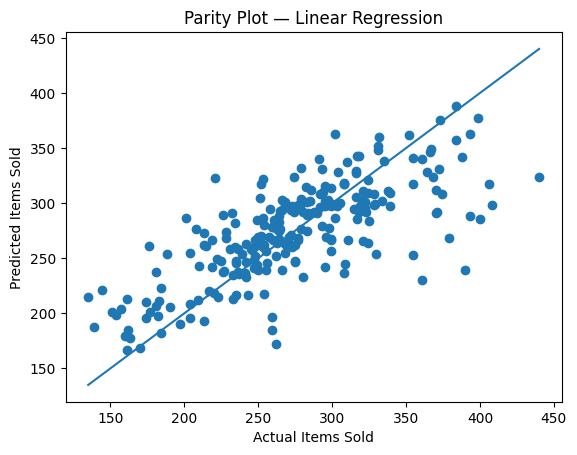

In [77]:
# Parity Plot — Linear Regression

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, lr_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Parity Plot — Linear Regression")
plt.show()

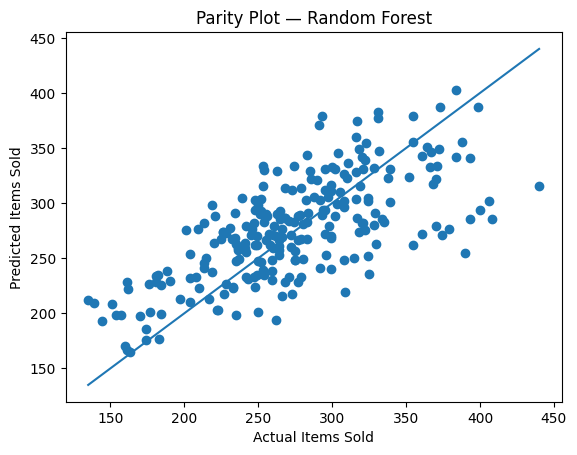

In [78]:
# Parity Plot — Random Forest

plt.figure()
plt.scatter(y_test, rf_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Parity Plot — Random Forest")
plt.show()

In [79]:
# Parity Plot Interpretation

# The parity plots compare predicted vs actual values of `items_sold`.

# - Linear Regression predictions are more closely aligned with the diagonal line
# indicating better accuracy.
# - Random Forest predictions show greater dispersion, suggesting higher prediction errors.

# This confirms that Linear Regression generalizes better on the test data.

In [80]:
# Feature Importance

# Extract feature importances
import pandas as pd

importances = rf_pipeline.named_steps['model'].feature_importances_
features = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(5)

,feature,importance
14,num__day_of_week,0.178442
10,cat__store_size_small,0.165466
7,cat__location_type_urban,0.130480
11,num__competition_density,0.101901
13,num__month,0.098886


In [81]:
### Feature Importance Interpretation

# The most influential features in predicting `items_sold` are:

# -day_of_week (0.178)** → Sales vary significantly across different days of the
# week, indicating strong weekly patterns
# -store_size_small (0.165)** → Smaller stores have a noticeable impact on sales performance
# -location_type_urban (0.130)** → Urban locations drive higher or more consistent sales
# -competition_density (0.102)** → Nearby competition affects store sales
# -month (0.099)** → Seasonal trends influence demand

# These results show that both temporal factors (day_of_week, month) and business
# factors (store size, location, competition) play a key role in determining sales.

In [82]:
# Final Conclusion

# - Linear Regression outperformed Random Forest, indicating a largely linear
# relationship in the data
# - Temporal features such as day of week and month significantly influence sales patterns
# - Business factors like store size, location, and competition also impact performance
# - The pipeline ensures a reproducible and scalable machine learning workflow

# This analysis highlights how both time-based and business-driven factors can be
# leveraged to accurately predict retail sales.